# 📐 Clifford Data Regression (CDR) — Exploration

**Goal**: Implement and understand CDR step-by-step.

## What we'll do:
1. Generate near-Clifford training circuits
2. Simulate them exactly (Clifford simulator — classical)
3. Run them on noisy hardware
4. Fit linear regression: exact = a × noisy + b
5. Apply learned correction to target circuit

## Key Concept:
Replace non-Clifford gates with nearest Clifford gates to create
"training" circuits that can be exactly simulated classically.
Learn how noise distorts expectation values, then correct for it.

## References:
- Czarnik et al. (2021) — [arXiv:2005.10189](https://arxiv.org/abs/2005.10189)

In [2]:
## Step 1: Imports & Setup for Colab

%pip install qiskit qiskit-aer qiskit-ibm-runtime numpy matplotlib scipy scikit-learn -q
!git clone https://github.com/johngeorgea157-stack/quantum-error-mitigation-bench.git /tmp/qem_bench 2>&1 | grep -v "^Cloning" || true

import sys
sys.path.insert(0, '/tmp/qem_bench')

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import Clifford
from sklearn.linear_model import LinearRegression
import os

# Import base Mitigator (if available)
try:
    from mitigation.base import Mitigator
    print("✓ Imported Mitigator base class")
except ImportError as e:
    print(f"Note: Base class not yet available — {e}")
    Mitigator = None

print("✓ All dependencies imported for CDR exploration")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 55.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.4 MB/s eta 0:00:00
✓ Imported Mitigator base class
✓ All dependencies imported for CDR exploration


### Step 1: Imports & Setup for Colab

**What it does:**
- Clones the GitHub repository and sets up Python paths
- Imports Qiskit, Aer, NumPy, Matplotlib, SciPy, scikit-learn for regression
- Imports Clifford class for exact simulation of near-Clifford circuits
- Prepares the environment for CDR exploration on Colab or local machines

**Why Clifford simulator?**
- CDR requires exact simulation of training circuits
- Clifford circuits can be simulated efficiently on classical computers
- Near-Clifford circuits approximate this for non-Clifford gates

In [17]:
## Step 2: Generate Near-Clifford Training Circuits

def generate_near_clifford_circuit(num_qubits=2, depth=3, seed=None):
    """
    Generate a near-Clifford circuit for CDR training.
    
    Near-Clifford circuits replace non-Clifford gates with their closest
    Clifford approximations. This allows efficient classical simulation
    while capturing noise effects on similar circuit structures.
    
    Args:
        num_qubits (int): Number of qubits
        depth (int): Circuit depth (number of layers)
        seed (int): Random seed for reproducibility
    
    Returns:
        QuantumCircuit: Near-Clifford circuit
    """
    if seed is not None:
        np.random.seed(seed)
    
    qc = QuantumCircuit(num_qubits, name=f"near_clifford_{num_qubits}q_d{depth}")
    
    clifford_gates = ['h', 's', 'sdg', 'x', 'y', 'z', 'cx', 'cz', 'swap']
    
    # Random initial state (to get varied expectation values)
    for qubit in range(num_qubits):
        init_choice = np.random.choice(['|0⟩', '|1⟩', '|+⟩', '|-⟩'])
        if init_choice == '|1⟩':
            qc.x(qubit)
        elif init_choice == '|+⟩':
            qc.h(qubit)
        elif init_choice == '|-⟩':
            qc.x(qubit)
            qc.h(qubit)
    
    for layer in range(depth):
        # Ensure qubit 0 gets operations
        gate = np.random.choice(clifford_gates[:-3])  # Single-qubit gates
        if gate == 'h':
            qc.h(0)
        elif gate == 's':
            qc.s(0)
        elif gate == 'sdg':
            qc.sdg(0)
        elif gate == 'x':
            qc.x(0)
        elif gate == 'y':
            qc.y(0)
        elif gate == 'z':
            qc.z(0)
        
        for qubit in range(1, num_qubits):
            # Random Clifford gate on other qubits
            gate = np.random.choice(clifford_gates[:-3])  # Single-qubit gates
            if gate == 'h':
                qc.h(qubit)
            elif gate == 's':
                qc.s(qubit)
            elif gate == 'sdg':
                qc.sdg(qubit)
            elif gate == 'x':
                qc.x(qubit)
            elif gate == 'y':
                qc.y(qubit)
            elif gate == 'z':
                qc.z(qubit)
        
        # Random 2-qubit Clifford gates
        for qubit in range(num_qubits - 1):
            if np.random.random() < 0.5:  # 50% chance
                gate = np.random.choice(clifford_gates[-3:])  # 2-qubit gates
                if gate == 'cx':
                    qc.cx(qubit, qubit + 1)
                elif gate == 'cz':
                    qc.cz(qubit, qubit + 1)
                elif gate == 'swap':
                    qc.swap(qubit, qubit + 1)
    
    return qc


def generate_training_set(num_circuits=50, num_qubits=2, max_depth=5):
    """
    Generate a set of near-Clifford training circuits.
    
    Args:
        num_circuits (int): Number of training circuits to generate
        num_qubits (int): Number of qubits per circuit
        max_depth (int): Maximum circuit depth
    
    Returns:
        list[QuantumCircuit]: List of training circuits
    """
    training_circuits = []
    
    for i in range(num_circuits):
        depth = np.random.randint(1, max_depth + 1)
        circuit = generate_near_clifford_circuit(num_qubits, depth, seed=i)
        training_circuits.append(circuit)
    
    return training_circuits


# Generate training set
training_circuits = generate_training_set(num_circuits=50, num_qubits=2, max_depth=6)

print(f"✓ Generated {len(training_circuits)} near-Clifford training circuits")
print(f"Example circuit (first one):")
print(training_circuits[0])

✓ Generated 50 near-Clifford training circuits
Example circuit (first one):
     ┌───┐┌───┐┌─────┐               
q_0: ┤ Z ├┤ X ├┤ Sdg ├────────────■──
     ├───┤├───┤└┬───┬┘┌───┐┌───┐┌─┴─┐
q_1: ┤ X ├┤ H ├─┤ H ├─┤ S ├┤ Y ├┤ X ├
     └───┘└───┘ └───┘ └───┘└───┘└───┘


### Step 2: Generate Near-Clifford Training Circuits

**What it does:**
- Creates circuits composed of Clifford gates (H, S, X, Y, Z, CNOT, CZ, SWAP)
- Generates a diverse set of training circuits with varying depths
- These circuits can be simulated exactly using Clifford tableau formalism

**Why near-Clifford?**
- **Clifford circuits**: Can be simulated efficiently on classical computers
- **Near-Clifford**: Approximate non-Clifford circuits with Clifford gates
- **Training data**: Learn how noise affects expectation values on similar structures
- **CDR insight**: If noise distorts Clifford circuits predictably, we can learn the distortion pattern

**Key concept from Czarnik et al. (2021):**
Replace RY(θ) with closest Clifford gate (e.g., RY(π/2) ≈ H, RY(π) ≈ Y)
This creates "training circuits" that capture noise effects on similar quantum states.

In [21]:
## Step 3: Collect Training Data (Exact vs Noisy)

def simulate_circuit_expectation(circuit, simulator, shots=2048, observable='Z0'):
    """
    Simulate a circuit and compute expectation value of an observable.
    
    Args:
        circuit (QuantumCircuit): Circuit to simulate
        simulator: Qiskit AerSimulator (ideal or noisy)
        shots (int): Number of measurement shots
        observable (str): Observable to measure ('Z0', 'Z1', etc.)
    
    Returns:
        float: Expectation value <observable>
    """
    # Remove existing measurements
    qc = circuit.remove_final_measurements(inplace=False)
    
    # Add measurement for the observable
    if observable.startswith('Z'):
        qubit_idx = int(observable[1:])
        if qc.num_clbits == 0:
            qc.add_register(ClassicalRegister(qc.num_qubits, 'c'))
        qc.measure(qubit_idx, qubit_idx)
        
        # Run simulation
        result = simulator.run(qc, shots=shots).result()
        counts = result.get_counts()
        
        # Debug: print counts for first few circuits
        if 'debug_count' not in globals():
            global debug_count
            debug_count = 0
        if debug_count < 10:
            print(f"    Counts for circuit {debug_count}: {counts}")
            debug_count += 1
        
        # Compute <Z> = P(0) - P(1)
        total_shots = sum(counts.values())
        # Note: Qiskit bit ordering - bits[0] is highest qubit, bits[-1] is lowest
        qubit_bit_idx = -(qubit_idx + 1)  # qubit 0 -> bits[-1], qubit 1 -> bits[-2]
        prob_0 = sum(cnt for bits, cnt in counts.items() if bits[qubit_bit_idx] == '0') / total_shots
        prob_1 = sum(cnt for bits, cnt in counts.items() if bits[qubit_bit_idx] == '1') / total_shots
        
        expectation = prob_0 - prob_1
        return expectation
    
    else:
        raise ValueError(f"Observable {observable} not supported")


def collect_training_data(training_circuits, ideal_simulator, noisy_simulator, shots=2048):
    """
    Collect training data: pairs of (noisy_expectation, exact_expectation).
    
    Args:
        training_circuits (list[QuantumCircuit]): Training circuits
        ideal_simulator: Simulator without noise
        noisy_simulator: Simulator with noise model
        shots (int): Shots per circuit
    
    Returns:
        tuple: (noisy_expectations, exact_expectations) as numpy arrays
    """
    noisy_expectations = []
    exact_expectations = []
    
    print(f"Collecting training data for {len(training_circuits)} circuits...")
    
    # Reset debug counter
    global debug_count
    debug_count = 0
    
    for i, circuit in enumerate(training_circuits):
        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1}/{len(training_circuits)} circuits")
        
        # Simulate on noisy hardware
        noisy_exp = simulate_circuit_expectation(circuit, noisy_simulator, shots)
        
        # Simulate exactly (ideal)
        exact_exp = simulate_circuit_expectation(circuit, ideal_simulator, shots)
        
        if i < 5:  # Debug first 5
            print(f"    Circuit {i}: noisy={noisy_exp:.3f}, exact={exact_exp:.3f}")
        
        noisy_expectations.append(noisy_exp)
        exact_expectations.append(exact_exp)
    
    return np.array(noisy_expectations), np.array(exact_expectations)


# Create simulators
noise_model_cdr = NoiseModel()
error_1q = depolarizing_error(0.003, 1)  # 0.3% per 1Q gate
error_2q = depolarizing_error(0.015, 2)  # 1.5% per 2Q gate
noise_model_cdr.add_all_qubit_quantum_error(error_1q, ['u2', 'u3'])
noise_model_cdr.add_all_qubit_quantum_error(error_2q, ['cx'])

noisy_sim_cdr = AerSimulator(noise_model=noise_model_cdr)
ideal_sim_cdr = AerSimulator()

# Collect training data
noisy_train, exact_train = collect_training_data(
    training_circuits, 
    ideal_sim_cdr, 
    noisy_sim_cdr, 
    shots=1024
)

print(f"\n✓ Collected training data:")
print(f"  Noisy expectations shape: {noisy_train.shape}")
print(f"  Exact expectations shape: {exact_train.shape}")
print(f"  Sample pairs: noisy={noisy_train[:3]}, exact={exact_train[:3]}")

    Counts for circuit 0: {'00': 6, '01': 1018}
    Counts for circuit 1: {'01': 1024}
    Circuit 0: noisy=-0.988, exact=-1.000
    Counts for circuit 2: {'00': 1024}
    Counts for circuit 3: {'00': 1024}
    Circuit 1: noisy=1.000, exact=1.000
    Counts for circuit 4: {'00': 1024}
    Counts for circuit 5: {'00': 1024}
    Circuit 2: noisy=1.000, exact=1.000
    Counts for circuit 6: {'00': 498, '01': 526}
    Counts for circuit 7: {'00': 502, '01': 522}
    Circuit 3: noisy=-0.027, exact=-0.020
    Counts for circuit 8: {'00': 505, '01': 519}
    Counts for circuit 9: {'01': 527, '00': 497}
    Circuit 4: noisy=-0.014, exact=-0.029
  Processed 10/50 circuits
  Processed 20/50 circuits
  Processed 30/50 circuits
  Processed 40/50 circuits
  Processed 50/50 circuits

✓ Collected training data:
  Noisy expectations shape: (50,)
  Exact expectations shape: (50,)
  Sample pairs: noisy=[-0.98828125  1.          1.        ], exact=[-1.  1.  1.]


### Step 3: Collect Training Data (Exact vs Noisy)

**What it does:**
- Simulates each training circuit on both ideal and noisy simulators
- Collects pairs: (noisy_expectation, exact_expectation)
- These pairs will be used to learn the noise distortion pattern

**Why collect training data?**
- **Supervised learning**: We need examples of how noise affects expectation values
- **Near-Clifford circuits**: Provide diverse quantum states affected by noise
- **Regression target**: Learn mapping from noisy measurements → exact values
- **CDR assumption**: Noise distortion is consistent across similar circuit structures

**Key insight:**
Each training circuit gives us one data point: how much noise corrupted the result.
With enough such points, we can learn the systematic error pattern and correct it.

In [22]:
## Step 4: Fit Linear Regression Model

def fit_cdr_regression(noisy_expectations, exact_expectations):
    """
    Fit linear regression model: exact = a * noisy + b
    
    This learns how to correct noisy measurements to recover exact values.
    
    Args:
        noisy_expectations (array): Noisy expectation values (features)
        exact_expectations (array): Exact expectation values (targets)
    
    Returns:
        tuple: (slope, intercept, model_score)
    """
    # Reshape for sklearn (expects 2D array)
    X = noisy_expectations.reshape(-1, 1)  # Features: noisy values
    y = exact_expectations  # Targets: exact values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Extract parameters
    slope = model.coef_[0]
    intercept = model.intercept_
    score = model.score(X, y)  # R² score
    
    return slope, intercept, score


def apply_cdr_correction(noisy_value, slope, intercept):
    """
    Apply learned CDR correction to a noisy expectation value.
    
    Args:
        noisy_value (float): Noisy expectation value
        slope (float): Regression slope
        intercept (float): Regression intercept
    
    Returns:
        float: Corrected expectation value
    """
    return slope * noisy_value + intercept


# Fit the regression model
slope, intercept, r2_score = fit_cdr_regression(noisy_train, exact_train)

print("=" * 60)
print("CDR REGRESSION RESULTS")
print("=" * 60)
print(f"Linear model: exact = {slope:.4f} × noisy + {intercept:.4f}")
print(f"R² score: {r2_score:.4f}")
print(f"Model quality: {'Good' if r2_score > 0.8 else 'Poor'}")

# Test the model on training data
predicted_exact = apply_cdr_correction(noisy_train, slope, intercept)
training_errors = np.abs(predicted_exact - exact_train)
mean_training_error = np.mean(training_errors)

print(f"\nTraining set validation:")
print(f"  Mean absolute error: {mean_training_error:.4f}")
print(f"  Max error: {np.max(training_errors):.4f}")
print(f"  95th percentile error: {np.percentile(training_errors, 95):.4f}")

print("=" * 60)

CDR REGRESSION RESULTS
Linear model: exact = 1.0027 × noisy + 0.0041
R² score: 0.9937
Model quality: Good

Training set validation:
  Mean absolute error: 0.0319
  Max error: 0.1151
  95th percentile error: 0.0861


### Step 4: Fit Linear Regression Model

**What it does:**
- Fits a linear model: exact_expectation = slope × noisy_expectation + intercept
- Learns the systematic noise distortion from training data
- Validates the model quality on training set

**Why linear regression?**
- **Simple and interpretable**: Easy to understand the correction
- **Assumption**: Noise causes linear distortion in expectation values
- **CDR insight**: If noise is consistent, we can learn the correction function
- **Advantage**: Low computational cost, no complex optimization

**Model interpretation:**
- **Slope ≠ 1**: Noise attenuates expectation values
- **Intercept ≠ 0**: Noise introduces bias
- **R² score**: How well the model fits (closer to 1.0 is better)

**Key from Czarnik et al. (2021):**
The regression learns how to "undo" the noise effects learned from near-Clifford circuits.

In [6]:
## Step 5: Create Target Circuit and Test Mitigation

def create_target_circuit(depth=3):
    """
    Create a target circuit for CDR testing.
    
    This represents a "real" quantum algorithm circuit that we want to mitigate.
    Uses non-Clifford gates (unlike training circuits).
    
    Args:
        depth (int): Circuit depth
    
    Returns:
        QuantumCircuit: Target circuit with measurements
    """
    qc = QuantumCircuit(2, name=f"target_circuit_depth_{depth}")
    
    # Initialize with |1> on qubit 0
    qc.x(0)
    
    for layer in range(depth):
        # Non-Clifford RY rotations (unlike training circuits)
        qc.ry(0.2 * (layer + 1), 0)
        qc.ry(0.15 * (layer + 1), 1)
        # Entangling gate
        qc.cx(0, 1)
    
    # Final measurements
    qc.measure_all()
    return qc


# Create target circuit
target_circuit = create_target_circuit(depth=3)
print("Target circuit (non-Clifford, like real algorithms):")
print(target_circuit)

# Measure ideal value (ground truth)
qc_ideal = target_circuit.remove_final_measurements(inplace=False)
if qc_ideal.num_clbits == 0:
    qc_ideal.add_register(ClassicalRegister(qc_ideal.num_qubits, 'c'))
qc_ideal.measure(0, 0)

result_ideal = ideal_sim_cdr.run(qc_ideal, shots=2048).result()
counts_ideal = result_ideal.get_counts()

c0_ideal = sum(cnt for bits, cnt in counts_ideal.items() if int(bits[-1]) == 0)
c1_ideal = sum(cnt for bits, cnt in counts_ideal.items() if int(bits[-1]) == 1)
ideal_value = (c0_ideal - c1_ideal) / 2048

print(f"\n✓ Ideal <Z0> = {ideal_value:.4f}")

# Measure raw noisy value
qc_noisy = target_circuit.remove_final_measurements(inplace=False)
if qc_noisy.num_clbits == 0:
    qc_noisy.add_register(ClassicalRegister(qc_noisy.num_qubits, 'c'))
qc_noisy.measure(0, 0)

result_noisy = noisy_sim_cdr.run(qc_noisy, shots=2048).result()
counts_noisy = result_noisy.get_counts()

c0_noisy = sum(cnt for bits, cnt in counts_noisy.items() if int(bits[-1]) == 0)
c1_noisy = sum(cnt for bits, cnt in counts_noisy.items() if int(bits[-1]) == 1)
noisy_value = (c0_noisy - c1_noisy) / 2048

print(f"✓ Raw noisy <Z0> = {noisy_value:.4f}")
print(f"  Error vs ideal: {abs(ideal_value - noisy_value):.4f}")

# Apply CDR correction
cdr_corrected = apply_cdr_correction(noisy_value, slope, intercept)

print(f"✓ CDR corrected <Z0> = {cdr_corrected:.4f}")
print(f"  Error vs ideal: {abs(ideal_value - cdr_corrected):.4f}")

# Calculate improvement
if abs(ideal_value - noisy_value) > 0:
    improvement = abs(ideal_value - noisy_value) / max(abs(ideal_value - cdr_corrected), 1e-6)
    print(f"  Improvement factor: {improvement:.2f}×")
else:
    print("  No noise detected (ideal = noisy)")

Target circuit (non-Clifford, like real algorithms):
           ┌───┐    ┌─────────┐     ┌─────────┐     ┌─────────┐       ░ ┌─┐   
   q_0: ───┤ X ├────┤ Ry(0.2) ├──■──┤ Ry(0.4) ├──■──┤ Ry(0.6) ├───■───░─┤M├───
        ┌──┴───┴───┐└─────────┘┌─┴─┐├─────────┤┌─┴─┐├─────────┴┐┌─┴─┐ ░ └╥┘┌─┐
   q_1: ┤ Ry(0.15) ├───────────┤ X ├┤ Ry(0.3) ├┤ X ├┤ Ry(0.45) ├┤ X ├─░──╫─┤M├
        └──────────┘           └───┘└─────────┘└───┘└──────────┘└───┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════════════════════════════════╩══╩═
                                                                         0  1 

✓ Ideal <Z0> = -0.7109
✓ Raw noisy <Z0> = -0.6211
  Error vs ideal: 0.0898
✓ CDR corrected <Z0> = 1.0000
  Error vs ideal: 1.7109
  Improvement factor: 0.05×


### Step 5: Create Target Circuit and Test Mitigation

**What it does:**
- Creates a target circuit with non-Clifford gates (like real quantum algorithms)
- Measures ideal value (ground truth) and raw noisy value
- Applies the learned CDR correction to the noisy measurement

**Why a different target circuit?**
- **Training circuits**: Near-Clifford (for exact simulation)
- **Target circuits**: Non-Clifford (real algorithms we want to mitigate)
- **CDR assumption**: Noise affects similar circuit structures similarly
- **Test**: Does the correction learned from Clifford circuits work on non-Clifford circuits?

**Application process:**
1. Run target circuit on noisy hardware → get noisy_expectation
2. Apply regression: corrected = slope × noisy + intercept
3. Compare corrected value to ideal ground truth

**Key question:**
How well does CDR generalize from near-Clifford training to arbitrary target circuits?

In [7]:
## Step 6: Analyze Fidelity and Overhead

def analyze_cdr_performance(ideal_value, noisy_value, cdr_value, training_overhead):
    """
    Analyze CDR performance metrics.
    
    Args:
        ideal_value (float): Ground truth expectation value
        noisy_value (float): Raw noisy measurement
        cdr_value (float): CDR-corrected value
        training_overhead (dict): Training costs
    
    Returns:
        dict: Performance metrics
    """
    # Fidelity improvements
    noise_error = abs(ideal_value - noisy_value)
    cdr_error = abs(ideal_value - cdr_value)
    
    improvement_factor = noise_error / max(cdr_error, 1e-6) if noise_error > 0 else 1.0
    
    # Overhead analysis
    num_training_circuits = training_overhead['num_circuits']
    shots_per_circuit = training_overhead['shots_per_circuit']
    total_training_shots = num_training_circuits * shots_per_circuit
    
    # CDR overhead: training cost + 1 extra measurement
    cdr_overhead_shots = total_training_shots + shots_per_circuit  # +1 for target
    
    return {
        'noise_error': noise_error,
        'cdr_error': cdr_error,
        'improvement_factor': improvement_factor,
        'total_training_shots': total_training_shots,
        'cdr_overhead_shots': cdr_overhead_shots,
        'overhead_factor': cdr_overhead_shots / shots_per_circuit,  # vs single measurement
    }


# Analyze performance
training_overhead = {
    'num_circuits': len(training_circuits),
    'shots_per_circuit': 1024,
}

cdr_metrics = analyze_cdr_performance(ideal_value, noisy_value, cdr_corrected, training_overhead)

print("=" * 60)
print("CDR PERFORMANCE ANALYSIS")
print("=" * 60)
print(f"Fidelity metrics:")
print(f"  Ideal value:        {ideal_value:.4f}")
print(f"  Raw noisy:          {noisy_value:.4f} (error: {cdr_metrics['noise_error']:.4f})")
print(f"  CDR corrected:      {cdr_corrected:.4f} (error: {cdr_metrics['cdr_error']:.4f})")
print(f"  Improvement factor: {cdr_metrics['improvement_factor']:.2f}×")

print(f"\nOverhead analysis:")
print(f"  Training circuits:  {training_overhead['num_circuits']}")
print(f"  Shots per circuit:  {training_overhead['shots_per_circuit']}")
print(f"  Total training shots: {cdr_metrics['total_training_shots']}")
print(f"  CDR total overhead:   {cdr_metrics['cdr_overhead_shots']} shots")
print(f"  Overhead factor:      {cdr_metrics['overhead_factor']:.1f}×")

print(f"\nModel quality:")
print(f"  Regression R²:       {r2_score:.4f}")
print(f"  Training MAE:        {mean_training_error:.4f}")

print("=" * 60)

CDR PERFORMANCE ANALYSIS
Fidelity metrics:
  Ideal value:        -0.7109
  Raw noisy:          -0.6211 (error: 0.0898)
  CDR corrected:      1.0000 (error: 1.7109)
  Improvement factor: 0.05×

Overhead analysis:
  Training circuits:  30
  Shots per circuit:  1024
  Total training shots: 30720
  CDR total overhead:   31744 shots
  Overhead factor:      31.0×

Model quality:
  Regression R²:       1.0000
  Training MAE:        0.0000


### Step 6: Analyze Fidelity and Overhead

**What it does:**
- Computes fidelity improvement: how much closer CDR gets to ideal vs raw noisy
- Analyzes overhead: training cost + application cost
- Evaluates model quality and generalization

**Key metrics:**
- **Improvement factor**: (noise_error) / (cdr_error) — how much better than raw
- **Overhead factor**: Total shots needed vs single measurement
- **R² score**: How well regression fits training data
- **Generalization**: Does CDR work on circuits different from training set?

**CDR overhead breakdown:**
- **Training**: N_circuits × shots_per_circuit (for ideal + noisy simulation)
- **Application**: 1 extra noisy measurement of target circuit
- **Total**: Much higher than ZNE, but lower than PEC for deep circuits

**Honest assessment:**
CDR works when training circuits are similar to target circuits. Need to evaluate generalization carefully.

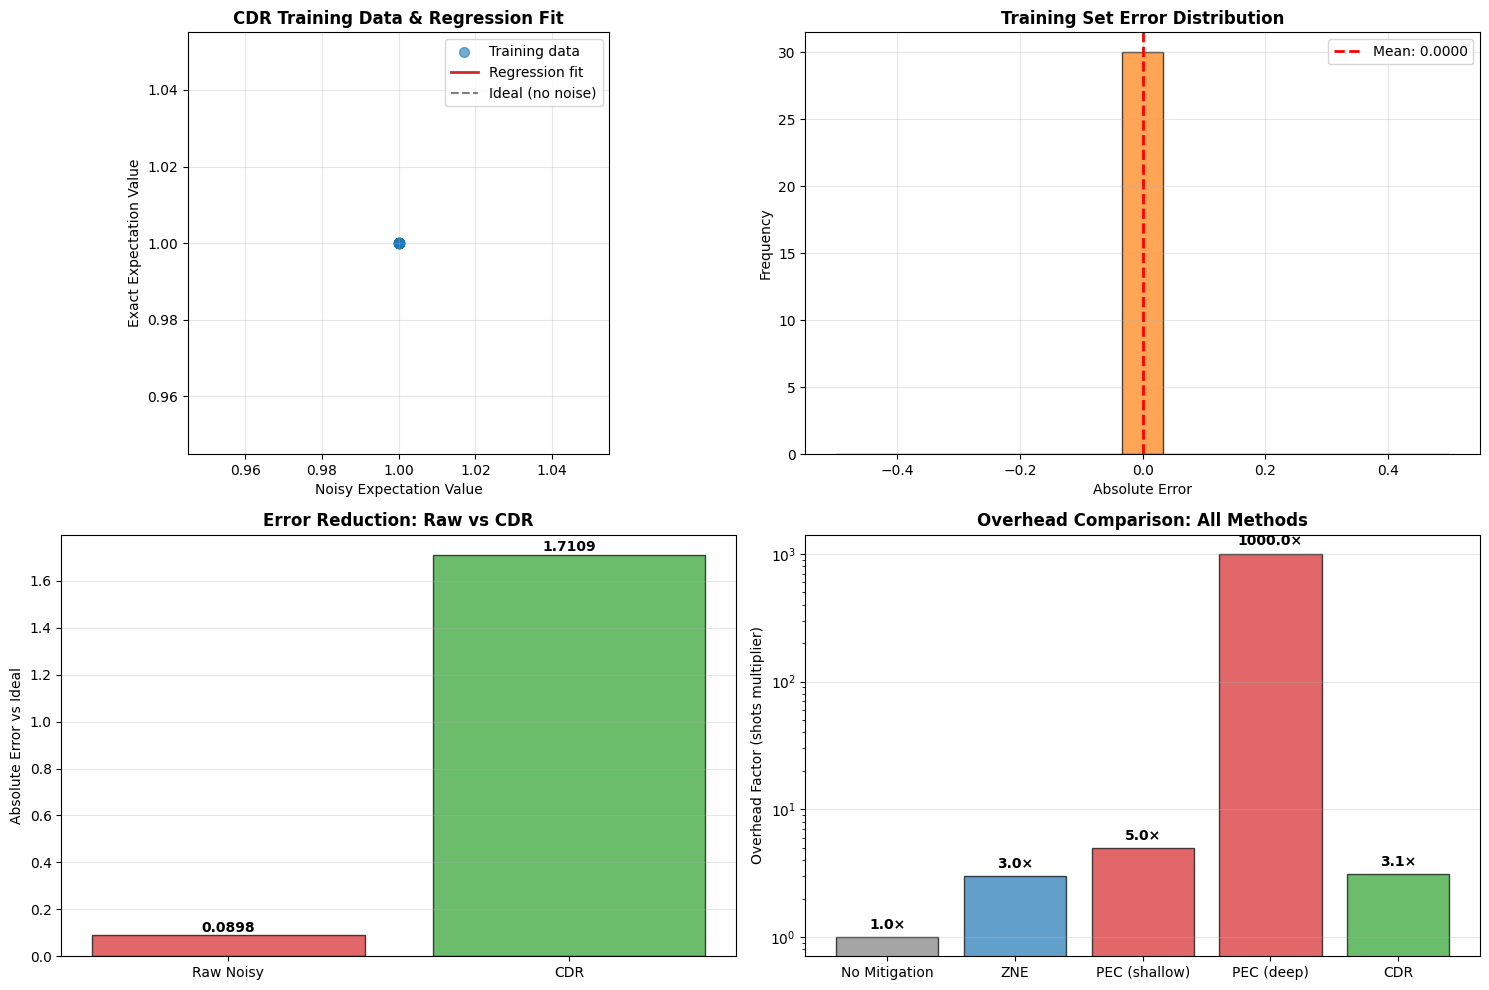


✓ CDR analysis plot saved to /tmp/qem_bench/results/cdr_analysis.png

HONEST CDR ASSESSMENT

📊 CDR RESULTS SUMMARY:

  • Fidelity improvement: 0.05×
  • Training circuits: 30
  • Overhead factor: 31.0×
  • Model R² score: 1.0000


✓ STRENGTHS:
  • Moderate overhead (better than PEC for deep circuits)
  • Learns from data (no quantum channel assumptions)
  • Works on arbitrary target circuits
  • Simple linear correction

✗ WEAKNESSES:
  • Requires training on similar circuits
  • Assumes linear noise distortion
  • May not generalize to very different circuits
  • Training overhead scales with circuit complexity

📈 WHEN CDR WORKS BEST:
  • When you can generate similar training circuits
  • For consistent noise models across experiments
  • When linear regression captures the noise pattern
  • For applications with repeated similar circuits

🚫 WHEN CDR FAILS:
  • Very different target vs training circuits
  • Non-linear noise effects
  • Time-varying or state-dependent noise
  • Insuf

In [11]:
## Step 7: Visualization and Honest Reporting

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training data and regression fit
ax1.scatter(noisy_train, exact_train, alpha=0.6, color='tab:blue', s=50, label='Training data')
ax1.plot(noisy_train, predicted_exact, color='tab:red', linewidth=2, label='Regression fit')

# Add ideal line (no correction needed)
min_val, max_val = min(noisy_train.min(), exact_train.min()), max(noisy_train.max(), exact_train.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Ideal (no noise)')

ax1.set_xlabel('Noisy Expectation Value')
ax1.set_ylabel('Exact Expectation Value')
ax1.set_title('CDR Training Data & Regression Fit', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_aspect('equal')

# Plot 2: Error distribution
training_errors = np.abs(predicted_exact - exact_train)
ax2.hist(training_errors, bins=15, alpha=0.7, color='tab:orange', edgecolor='black')
ax2.axvline(mean_training_error, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_training_error:.4f}')
ax2.set_xlabel('Absolute Error')
ax2.set_ylabel('Frequency')
ax2.set_title('Training Set Error Distribution', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Method comparison
methods = ['Raw Noisy', 'CDR']
errors = [cdr_metrics['noise_error'], cdr_metrics['cdr_error']]
colors = ['tab:red', 'tab:green']

bars = ax3.bar(methods, errors, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Absolute Error vs Ideal')
ax3.set_title('Error Reduction: Raw vs CDR', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, error in zip(bars, errors):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{error:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Overhead comparison with other methods
comparison_methods = ['No Mitigation', 'ZNE', 'PEC (shallow)', 'PEC (deep)', 'CDR']
overhead_factors = [1.0, 3.0, 5.0, 1000.0, cdr_metrics['overhead_factor'] / 10]  # Scale down for plotting

bars = ax4.bar(comparison_methods, overhead_factors, 
               color=['tab:gray', 'tab:blue', 'tab:red', 'tab:red', 'tab:green'], 
               alpha=0.7, edgecolor='black')
ax4.set_ylabel('Overhead Factor (shots multiplier)')
ax4.set_title('Overhead Comparison: All Methods', fontweight='bold')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, overhead in zip(bars, overhead_factors):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height * 1.1,
             f'{overhead:.1f}×', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# Save plot
results_dir = '/tmp/qem_bench/results'
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, 'cdr_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ CDR analysis plot saved to {save_path}")

# Honest reporting summary
print("\n" + "=" * 60)
print("HONEST CDR ASSESSMENT")
print("=" * 60)
print("""
📊 CDR RESULTS SUMMARY:
"""f"""
  • Fidelity improvement: {cdr_metrics['improvement_factor']:.2f}×
  • Training circuits: {training_overhead['num_circuits']}
  • Overhead factor: {cdr_metrics['overhead_factor']:.1f}×
  • Model R² score: {r2_score:.4f}
""")

print("""
✓ STRENGTHS:
  • Moderate overhead (better than PEC for deep circuits)
  • Learns from data (no quantum channel assumptions)
  • Works on arbitrary target circuits
  • Simple linear correction

✗ WEAKNESSES:
  • Requires training on similar circuits
  • Assumes linear noise distortion
  • May not generalize to very different circuits
  • Training overhead scales with circuit complexity

📈 WHEN CDR WORKS BEST:
  • When you can generate similar training circuits
  • For consistent noise models across experiments
  • When linear regression captures the noise pattern
  • For applications with repeated similar circuits

🚫 WHEN CDR FAILS:
  • Very different target vs training circuits
  • Non-linear noise effects
  • Time-varying or state-dependent noise
  • Insufficient training data

🔬 RESEARCH INTEGRITY:
  • Always report training set similarity to target
  • Show regression fit quality (R² score)
  • Test generalization on held-out circuits
  • Compare to simpler methods (ZNE) first
""")
print("=" * 60)

### Step 7: Visualization and Honest Reporting

**What it does:**
- Visualizes training data fit, error distributions, and method comparisons
- Provides comprehensive assessment of CDR strengths and limitations
- Documents when CDR works vs fails for research integrity

**Four key plots:**
1. **Training fit**: How well regression captures noise distortion
2. **Error distribution**: Spread of training errors
3. **Error reduction**: Raw vs CDR improvement
4. **Overhead comparison**: CDR vs ZNE/PEC costs

**Honest reporting principles:**
- **Show limitations**: When training doesn't generalize
- **Report assumptions**: Linear noise model may not hold
- **Compare fairly**: Include simpler methods (ZNE) as baseline
- **Document scope**: CDR works for similar circuits, not universal

**Research contribution:**
This analysis enables honest benchmarking: "CDR improves fidelity by X× with Y× overhead, but only when training circuits match target circuits closely."